In [25]:
import pandas as pd
import time
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import r2_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [26]:
data_path = "student-lifestyle-and-stress-dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
5,college,4.914849,NaN,2.141137,85.144095,3.0,5.0,5.0,0
6,college,6.621709,5.261762,4.879102,NaN,4.0,7.0,7.0,0
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
8,college,8.085219,5.043731,4.660604,89.564367,3.0,2.0,7.0,0
9,college,4.627502,4.743084,5.579822,95.794315,5.0,5.0,10.0,0


In [27]:
# Reading Null Data
print(df.shape)
print(f"Reading Missing Values : {df.isnull().sum().max()}")

(25500, 9)
Reading Missing Values : 1333


Missing Values
Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
dtype: int64


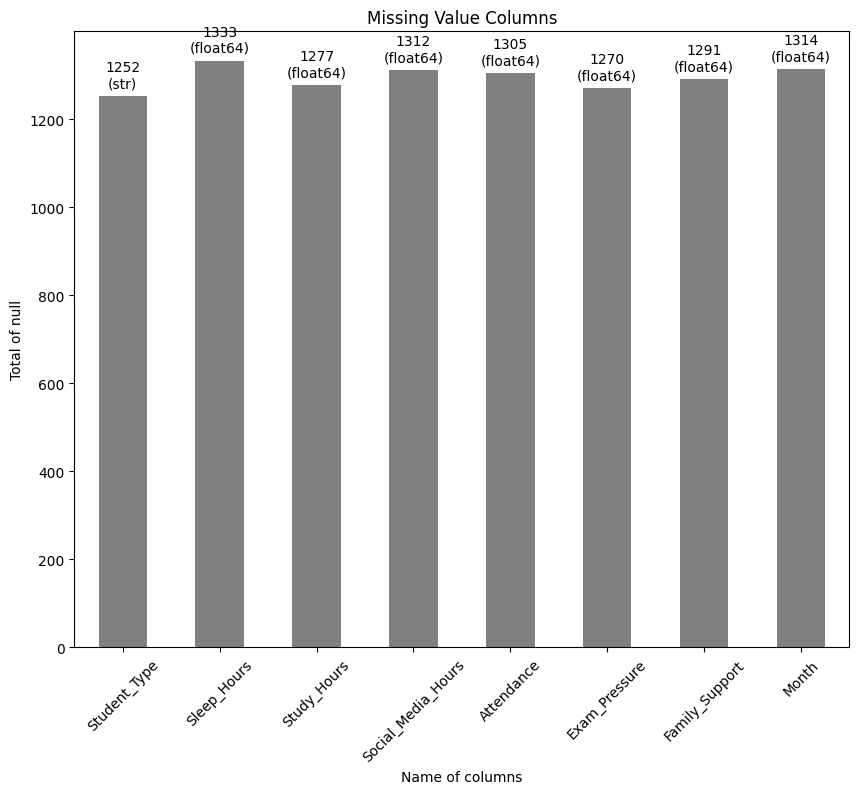

In [28]:
missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print("Missing Values")

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,8))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=45)
plt.show()

In [29]:

num_cols_impute = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
                   'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']

num_imputer = SimpleImputer(strategy='median')

df[num_cols_impute] = num_imputer.fit_transform(df[num_cols_impute])

cat_imputer = SimpleImputer(strategy='most_frequent')

df[['Student_Type']] = cat_imputer.fit_transform(df[['Student_Type']])

print("Fixing Missing Values =", df.isnull().sum().max())

Fixing Missing Values = 0


In [30]:
# Preprocessing 

dfe = df.copy()

print(dfe['Student_Type'].unique())

dfe['Student_Type'] = dfe['Student_Type'].map({'school' : 0, 'college' : 1, 'working_student' : 2})

<StringArray>
['school', 'college', 'working_student']
Length: 3, dtype: str


In [31]:
dfe.dtypes

Student_Type            int64
Sleep_Hours           float64
Study_Hours           float64
Social_Media_Hours    float64
Attendance            float64
Exam_Pressure         float64
Family_Support        float64
Month                 float64
Stress_Level            int64
dtype: object

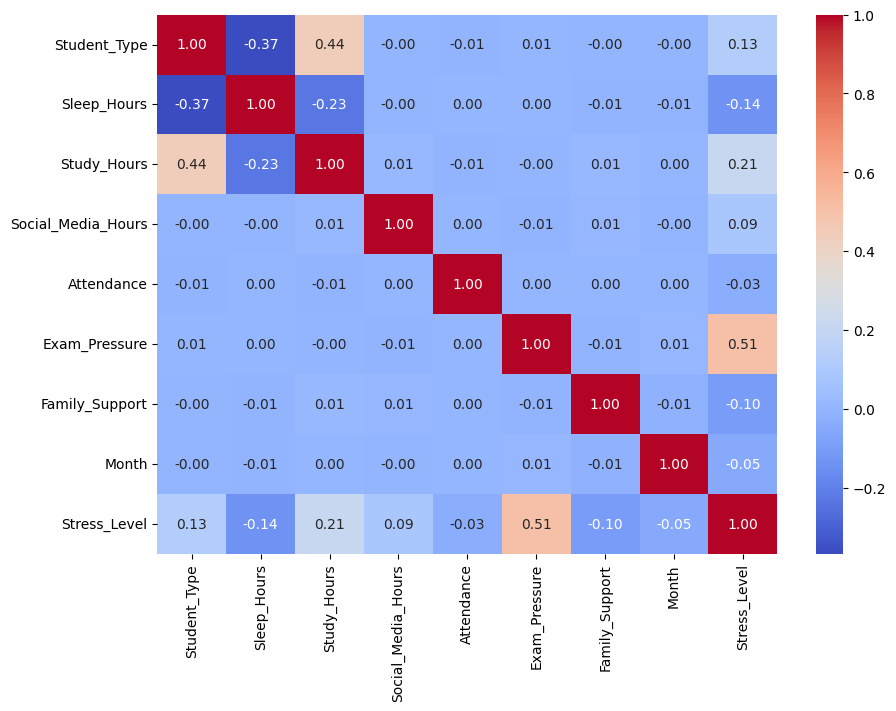

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f') 

plt.show()

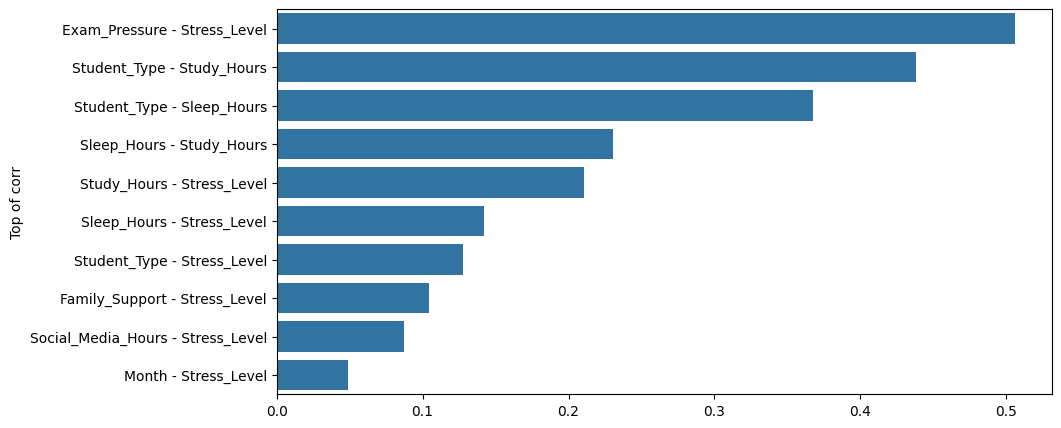

In [33]:
# Feature comparison visual data

corr_matrix = dfe.corr().abs()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


In [34]:
# Train Test

y = dfe['Stress_Level']

X = dfe.drop('Stress_Level', axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print("X train size : ", len(y_train)) 
print("y test size : ", len(y_valid))

print("\nLabel test count data")
print(y_valid.value_counts())
print("Length of data", len(y_valid))


X train size :  20400
y test size :  5100

Label test count data
Stress_Level
0    3545
1    1555
Name: count, dtype: int64
Length of data 5100


In [35]:
smote = SMOTETomek()

print(f"Data before balancing {print(len(y_train))}")

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Data After Rebalancing {print(len(y_train_smote))}")

print(df['Stress_Level'].unique())

20400
Data before balancing None
28076
Data After Rebalancing None
[1 0]


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Time predict : 111.25201187499988 seconds


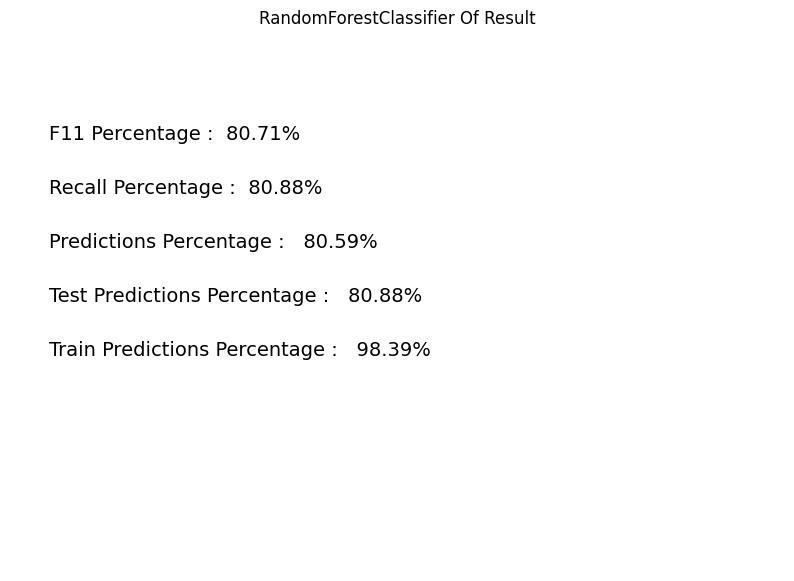

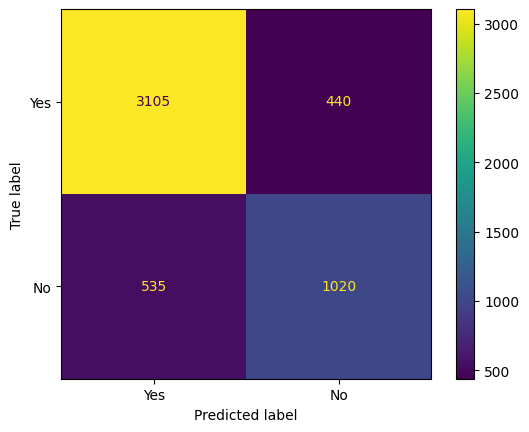


Calculating Learning Curve...
Best param : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 493}


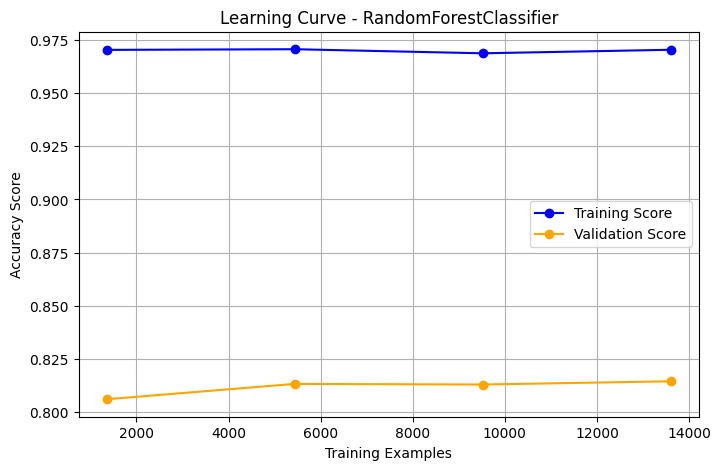

In [36]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2']
}


model_rfc = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions,
    n_iter=30,          # try 30 random combinations
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Yes", "No"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

best_model = model_rfc.best_estimator_

print(f"Best param : {model_rfc.best_params_}")

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 4)

if hasattr(X_train_smote, 'values'):
    X_full = np.concatenate([X_train_smote.values, X_valid], axis=0)
else: 
    X_full = np.concatenate([X_train_smote, X_valid], axis=0)

y_full = np.concatenate((y_train_smote, y_valid))

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()
